# Notebook 04 — State-Level Policy Analysis

Aggregate plant-level risk scores to the state level to identify which states face the greatest exposure from thermoelectric water consumption.

**State Exposure Index** = consumption-weighted average risk score. States with many large overconsumers in stressed basins rank highest.

**Counterfactual**: what would aggregate consumption be if every Open (once-through) plant switched to Closed (recirculating tower) cooling?

**Units**: All water volumes in **megaliters (ML)** throughout.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
DATA_DIR = Path('..') / 'data' / 'processed'
FIG_DIR  = Path('..') / 'data' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / 'Power_Plant_Benchmarked.csv')
df = df[df['predicted_ceiling_90'].notna()].copy()

# Ensure ML columns exist
MG_TO_ML = 3.78541
if 'consumption_ML' not in df.columns:
    df['consumption_ML'] = df['consumption_mg'] * MG_TO_ML
if 'state_water_intensity_L_per_MWh' not in df.columns:
    df['state_water_intensity_L_per_MWh'] = df['state_water_intensity_gal_mwh'] * MG_TO_ML

df['bws_raw']       = df['bws_raw'].fillna(0)
df['excess_ratio']  = df['excess_pct_90'].clip(lower=0)
df['risk_score']    = df['excess_ratio'] * df['bws_raw']

print(f'Loaded: {len(df):,} benchmarked plant-years across {df["state"].nunique()} states')

Loaded: 2,237 benchmarked plant-years across 47 states


## 1. State Exposure Index

In [2]:
def weighted_mean(group, value_col, weight_col):
    w = group[weight_col]
    return (group[value_col] * w).sum() / w.sum() if w.sum() > 0 else 0

state_agg = df.groupby('state').apply(
    lambda g: pd.Series({
        'exposure_index':        weighted_mean(g, 'risk_score', 'consumption_ML'),
        'total_consumption_ML':  g['consumption_ML'].sum(),
        'n_plant_years':         len(g),
        'n_plants':              g['plant_code'].nunique(),
        'n_overconsumers':       g['overconsumer_90'].sum(),
        'overconsumer_pct':      g['overconsumer_90'].mean(),
        'mean_bws':              g['bws_raw'].mean(),
        'state_water_intensity': g['state_water_intensity_L_per_MWh'].mean(),
    })
, include_groups=False).reset_index().sort_values('exposure_index', ascending=False)

print('Top 15 states by Exposure Index:')
top15 = state_agg.head(15).copy()
top15['total_consumption_ML'] = top15['total_consumption_ML'].map('{:,.0f}'.format)
top15['overconsumer_pct']     = top15['overconsumer_pct'].map('{:.1%}'.format)
top15['exposure_index']       = top15['exposure_index'].round(4)
top15['mean_bws']             = top15['mean_bws'].round(3)
top15['state_water_intensity']= top15['state_water_intensity'].round(1)
print(top15.to_string(index=False))

Top 15 states by Exposure Index:
state  exposure_index total_consumption_ML  n_plant_years  n_plants  n_overconsumers overconsumer_pct  mean_bws  state_water_intensity
   NV          1.5587               30,004           42.0      12.0              4.0             9.5%     1.147                  196.8
   VA          0.5798               73,594           59.0      15.0              7.0            11.9%     0.340                  211.8
   MI          0.5192              534,792           41.0      14.0              9.0            22.0%     0.106                 1164.9
   IL          0.5191            1,174,289           59.0      16.0              9.0            15.3%     0.251                 1691.0
   CA          0.3111              138,835          120.0      32.0              3.0             2.5%     1.510                  182.3
   OK          0.2762              277,814           78.0      21.0             13.0            16.7%     0.341                  917.7
   KS          0.2450 

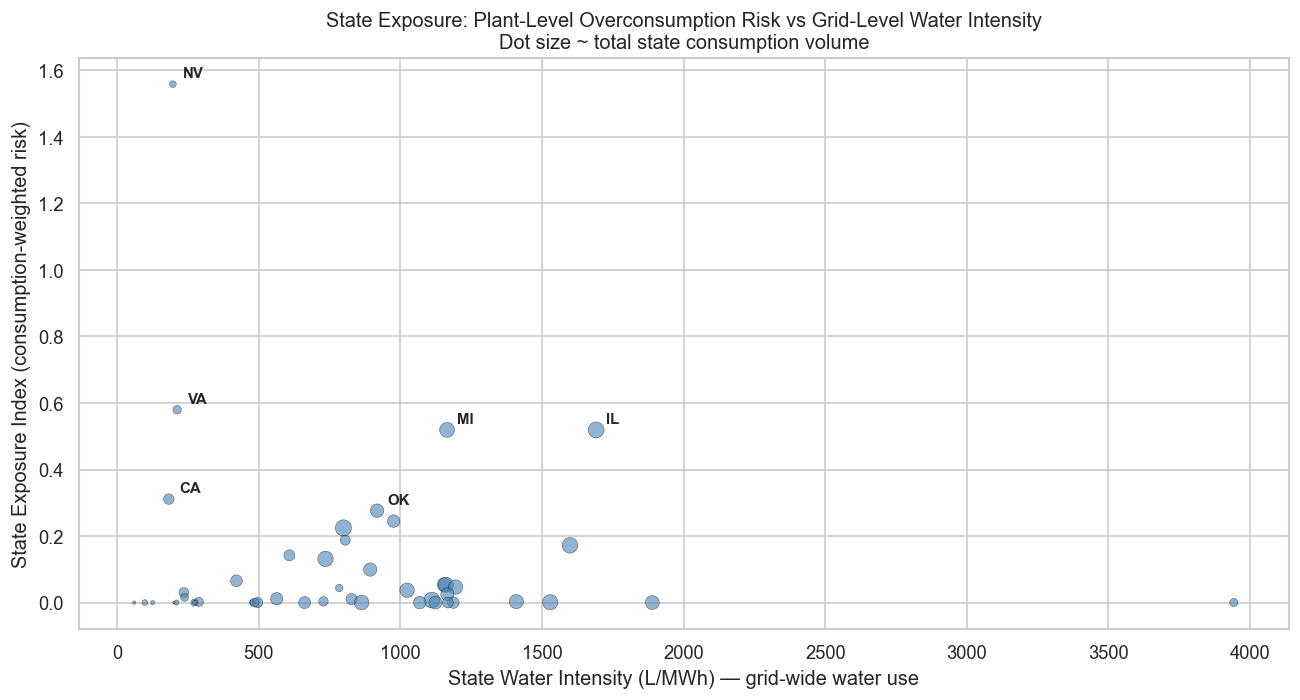

In [3]:
# Scatter: exposure_index vs state_water_intensity, label top 6
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(state_agg['state_water_intensity'], state_agg['exposure_index'],
           s=state_agg['total_consumption_ML'].rank() * 2,
           alpha=0.6, color='steelblue', edgecolors='black', linewidths=0.3)

for _, row in state_agg.head(6).iterrows():
    ax.annotate(row['state'],
                xy=(row['state_water_intensity'], row['exposure_index']),
                xytext=(6, 4), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_xlabel('State Water Intensity (L/MWh) — grid-wide water use')
ax.set_ylabel('State Exposure Index (consumption-weighted risk)')
ax.set_title('State Exposure: Plant-Level Overconsumption Risk vs Grid-Level Water Intensity\n'
             'Dot size ~ total state consumption volume')
plt.tight_layout()
plt.savefig(FIG_DIR / 'state_exposure.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: State Exposure Scatter

Each dot is a U.S. state. The axes show two different dimensions of water risk:

- **X-axis (State Water Intensity):** How much water the entire state grid uses per MWh — a structural measure of how water-dependent the state's power sector is
- **Y-axis (Exposure Index):** How many overconsumer plants exist in stressed watersheds — a measure of acute, plant-specific risk

**Why this matters:** A state can have high grid-level water intensity (lots of wet cooling overall) but low exposure (none of those plants are overconsumers in stressed basins). The most concerning states are in the **upper-right quadrant** — both structurally water-intensive AND home to acute overconsumers.

The labeled states (top 6) are the highest priority for policy attention. Their large dot sizes indicate they also have high total consumption volume.

## 2. Most Exposed States — Detailed Profile

In [4]:
top6_states = state_agg.head(6)['state'].tolist()
print(f'Top 6 most exposed states: {top6_states}')
print()

# Cooling technology mix for each
for state in top6_states:
    sub = df[df['state'] == state]
    mix = sub['cooling_category'].value_counts(normalize=True).map('{:.1%}'.format)
    total_ml = sub['consumption_ML'].sum()
    n_over   = sub['overconsumer_90'].sum()
    print(f'{state}: {total_ml:,.0f} ML total  |  {n_over} overconsumers  |  cooling mix: {mix.to_dict()}')

Top 6 most exposed states: ['NV', 'VA', 'MI', 'IL', 'CA', 'OK']

NV: 30,004 ML total  |  4 overconsumers  |  cooling mix: {'Dry-Hybrid': '66.7%', 'Closed': '33.3%'}
VA: 73,594 ML total  |  7 overconsumers  |  cooling mix: {'Closed': '52.5%', 'Dry-Hybrid': '47.5%'}
MI: 534,792 ML total  |  9 overconsumers  |  cooling mix: {'Closed': '65.9%', 'Open': '26.8%', 'Dry-Hybrid': '7.3%'}
IL: 1,174,289 ML total  |  9 overconsumers  |  cooling mix: {'Closed': '76.3%', 'Open': '18.6%', 'Dry-Hybrid': '5.1%'}
CA: 138,835 ML total  |  3 overconsumers  |  cooling mix: {'Closed': '61.7%', 'Dry-Hybrid': '38.3%'}
OK: 277,814 ML total  |  13 overconsumers  |  cooling mix: {'Closed': '100.0%'}


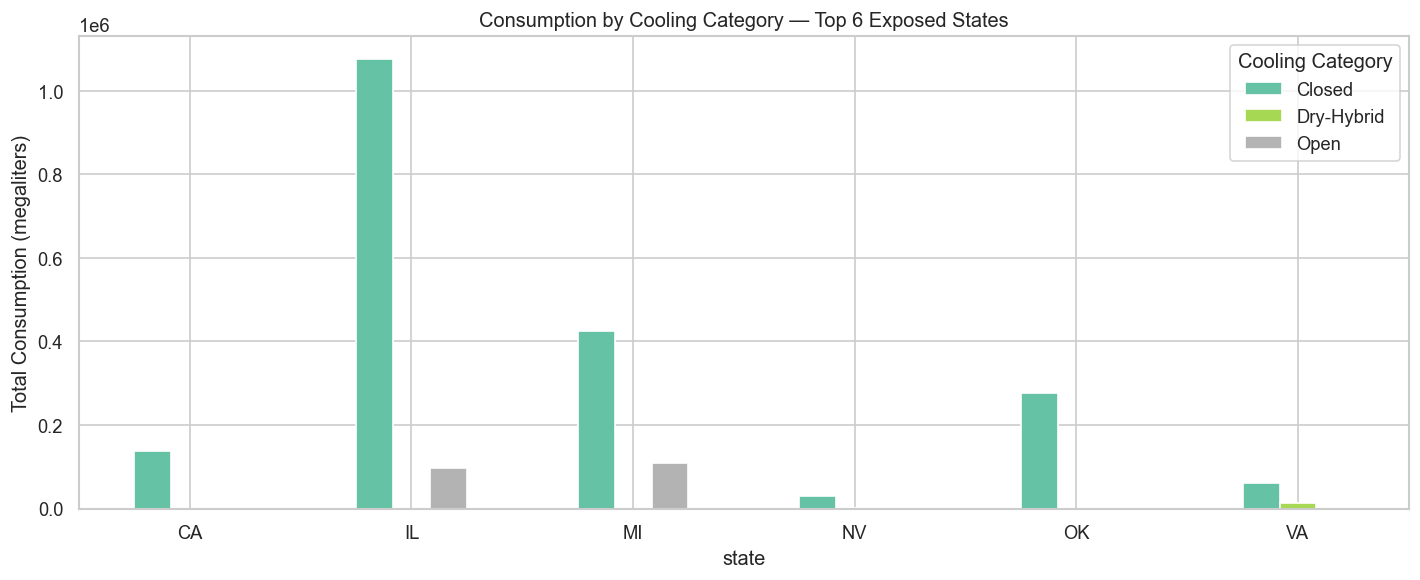

In [5]:
# Bar chart: total consumption by cooling category for top 6 states
top6_df = df[df['state'].isin(top6_states)]
cooling_by_state = (top6_df.groupby(['state','cooling_category'])['consumption_ML']
                    .sum().unstack(fill_value=0))

cooling_by_state.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.ylabel('Total Consumption (megaliters)')
plt.title('Consumption by Cooling Category — Top 6 Exposed States')
plt.xticks(rotation=0)
plt.legend(title='Cooling Category')
plt.tight_layout()
plt.show()

### Interpretation: Cooling Mix in Top Exposed States

This chart reveals the **underlying cause** of state-level exposure: the cooling technology mix.

- **Open (once-through) cooling** dominates water consumption in many top-exposed states. These systems pass enormous water volumes through the plant, and while much is discharged, the volumes are still problematic for local ecosystems.
- States that have already transitioned to **Closed (recirculating) cooling** show lower per-plant consumption.

**Key takeaway for presentation:** The technology mix is actionable — regulatory incentives to retrofit Open cooling systems to Closed towers could substantially reduce water risk. This leads directly to the counterfactual analysis below.

## 3. Counterfactual — Open → Closed Cooling Switch

In [6]:
# Intensity = consumption per MWh generated (ML/MWh)
df['consumption_intensity'] = df['consumption_ML'] / df['net_gen_mwh']

# Median intensity by cooling category (across all plants)
median_intensity = df.groupby('cooling_category')['consumption_intensity'].median()
print('Median water intensity by cooling category (ML per MWh):')
print(median_intensity.round(6).to_string())

closed_intensity = median_intensity.get('Closed', None)
open_intensity   = median_intensity.get('Open', None)
if closed_intensity and open_intensity:
    switch_ratio = closed_intensity / open_intensity
    print(f'\nIf Open plants operated at Closed efficiency:')
    print(f'  Closed median intensity: {closed_intensity:.6f} ML/MWh')
    print(f'  Open   median intensity: {open_intensity:.6f} ML/MWh')
    print(f'  Reduction ratio: {switch_ratio:.4f}  ({(1-switch_ratio)*100:.1f}% reduction)')

Median water intensity by cooling category (ML per MWh):
cooling_category
Closed        0.000969
Dry-Hybrid    0.000000
Open          0.001361

If Open plants operated at Closed efficiency:
  Closed median intensity: 0.000969 ML/MWh
  Open   median intensity: 0.001361 ML/MWh
  Reduction ratio: 0.7119  (28.8% reduction)


In [7]:
# Counterfactual per state
open_plants = df[df['cooling_category'] == 'Open'].copy()
open_plants['counterfactual_ML'] = open_plants['consumption_ML'] * switch_ratio
open_plants['savings_ML']        = open_plants['consumption_ML'] - open_plants['counterfactual_ML']

state_savings = (open_plants.groupby('state')
                 .agg(open_plants_count=('plant_code','nunique'),
                      actual_open_ML=('consumption_ML','sum'),
                      counterfactual_ML=('counterfactual_ML','sum'),
                      savings_ML=('savings_ML','sum'))
                 .sort_values('savings_ML', ascending=False)
                 .head(15))

print('Estimated ML saved per state if all Open plants switched to Closed cooling:')
print(state_savings.round(0).to_string())

total_savings = open_plants['savings_ML'].sum()
total_open    = open_plants['consumption_ML'].sum()
print(f'\nNational total savings: {total_savings:,.0f} ML  ({100*total_savings/total_open:.1f}% of Open-plant consumption)')

Estimated ML saved per state if all Open plants switched to Closed cooling:
       open_plants_count  actual_open_ML  counterfactual_ML  savings_ML
state                                                                  
TN                     3        204328.0           145468.0     58860.0
LA                     3        181861.0           129473.0     52388.0
AL                     3        172412.0           122745.0     49666.0
MN                     3        159312.0           113419.0     45893.0
PA                     5        146484.0           104287.0     42197.0
TX                     9        141322.0           100612.0     40710.0
IN                     4        125400.0            89276.0     36124.0
MI                     4        108960.0            77572.0     31388.0
IL                     3         96962.0            69031.0     27932.0
AR                     1         96131.0            68439.0     27692.0
NY                     1         77759.0            55359.0 

### Interpretation: Counterfactual Cooling Switch Analysis

This is the **policy-actionable result** of the entire analysis. The question: *"What if every Open (once-through) cooling plant switched to Closed (recirculating tower) cooling?"*

**Methodology:**
- Calculate the median water consumption intensity (ML per MWh) for Closed-cooling plants
- Calculate the same for Open-cooling plants
- Apply the ratio to estimate what each Open plant *would* consume if it operated at Closed efficiency
- Aggregate savings by state

**The bar chart shows:**
- **Coral bars** = actual current consumption from Open-cooling plants
- **Blue bars** = estimated consumption if those same plants used Closed cooling
- The gap between the bars = **potential water savings**

**Key takeaway:** The national total savings estimate quantifies the opportunity cost of maintaining legacy once-through cooling. This is a concrete, actionable policy recommendation backed by data.

**Caveat for the paper:** This is a *simplified* counterfactual — real cooling system retrofits involve capital costs, permitting, and potential efficiency losses that this analysis doesn't capture. Present it as an upper-bound estimate of the technical potential.

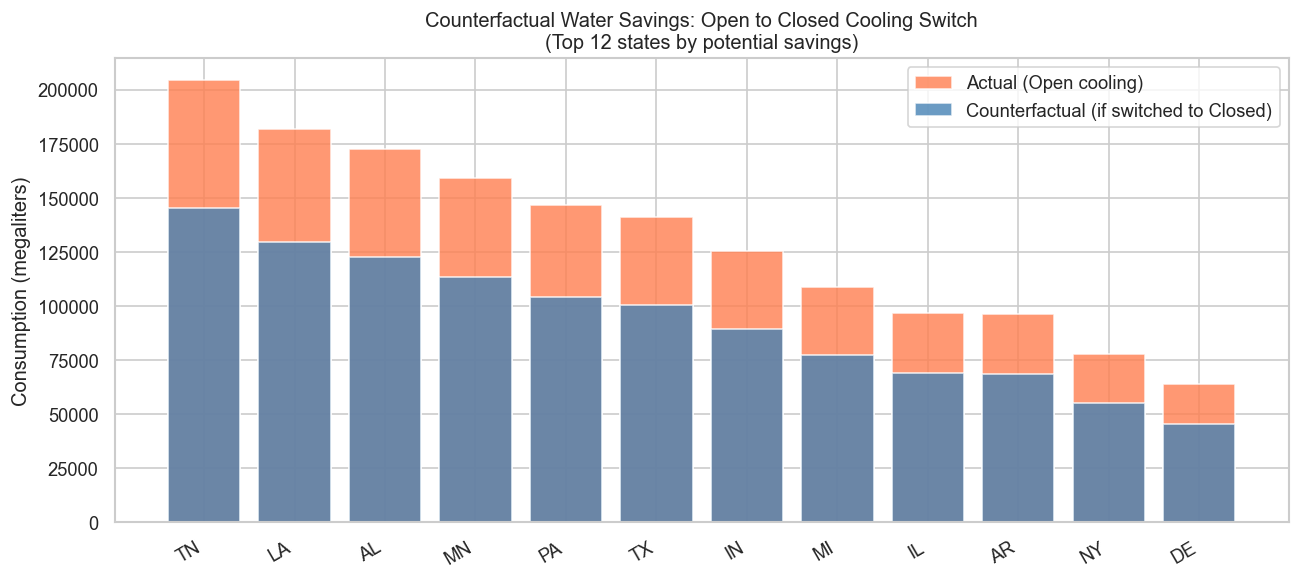

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
top_save = state_savings.head(12)
x = np.arange(len(top_save))
ax.bar(x, top_save['actual_open_ML'], label='Actual (Open cooling)', color='coral', alpha=0.8)
ax.bar(x, top_save['counterfactual_ML'], label='Counterfactual (if switched to Closed)', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top_save.index, rotation=30, ha='right')
ax.set_ylabel('Consumption (megaliters)')
ax.set_title('Counterfactual Water Savings: Open to Closed Cooling Switch\n(Top 12 states by potential savings)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'counterfactual_savings.png', dpi=150, bbox_inches='tight')
plt.show()